In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Setup completed successfully!")

Setup completed successfully!


In [2]:
df = pd.read_csv('Dataset for Data Analytics - Sheet1.csv')

print(df.head())

     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREE

In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1200, 14)


In [4]:
print(df.columns.tolist())

['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


In [5]:
print(df.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [6]:
df['CouponCode'] = df['CouponCode'].fillna(df['CouponCode'].mode()[0])

print(df.isnull().sum())

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [8]:
# Numerical columns
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

# Treat outliers using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Replace extreme values with lower/upper limits
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("Outliers treated successfully!")

Outliers treated successfully!


In [9]:
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].head())

0   2023-01-04
1   2024-08-23
2   2024-02-27
3   2023-10-15
4   2025-05-08
Name: Date, dtype: datetime64[ns]


In [10]:
# Feature 1: Extract month
df['OrderMonth'] = df['Date'].dt.month

# Feature 2: Extract year
df['OrderYear'] = df['Date'].dt.year

# Feature 3: Average value per item
df['AvgItemValue'] = df['TotalPrice'] / df['Quantity']

# Feature 4: Cart efficiency ratio
df['CartEfficiency'] = df['Quantity'] / df['ItemsInCart']

print(df[['OrderMonth', 'OrderYear', 'AvgItemValue', 'CartEfficiency']].head())

   OrderMonth  OrderYear  AvgItemValue  CartEfficiency
0           1       2023        570.62        0.714286
1           8       2024        151.35        0.666667
2           2       2024        550.68        0.625000
3          10       2023        273.19        0.200000
4           5       2025        626.01        0.500000


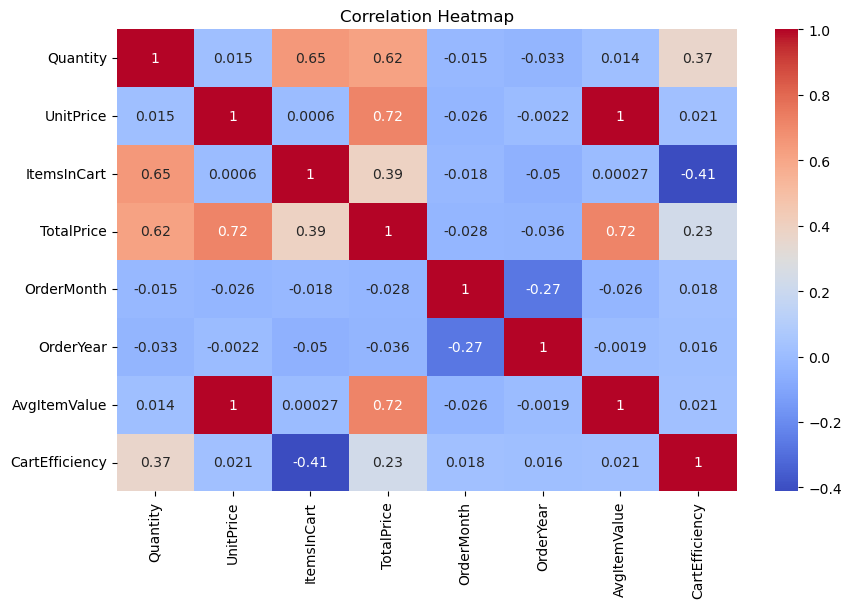

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

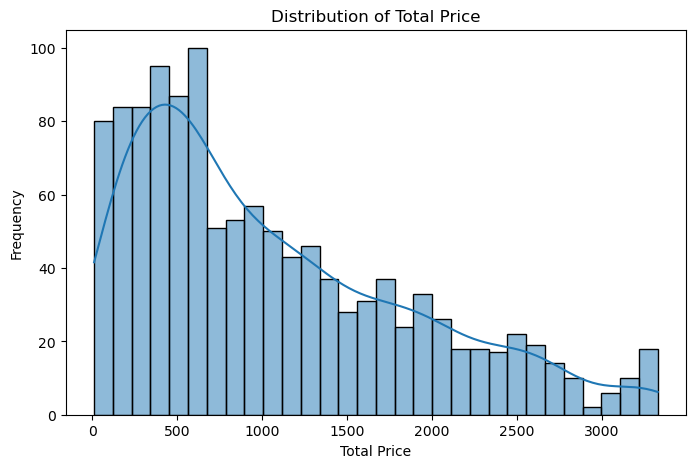

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['TotalPrice'], bins=30, kde=True)
plt.title('Distribution of Total Price')
plt.xlabel('Total Price')
plt.ylabel('Frequency')
plt.show()

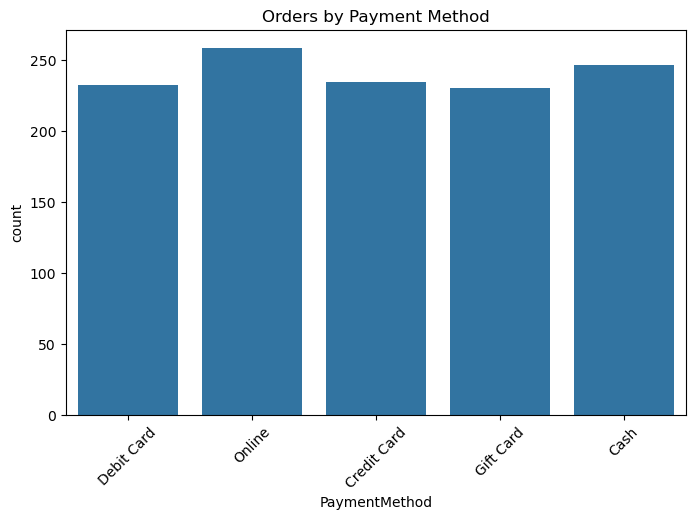

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='PaymentMethod', data=df)
plt.xticks(rotation=45)
plt.title('Orders by Payment Method')
plt.show()

In [14]:
df.to_csv('cleaned_ecommerce_dataset.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Conclusion

This project successfully transformed a raw e-commerce dataset into a clean, structured, and machine-learning-ready dataset. Missing values were handled using statistical imputation, outliers were treated using the IQR method, and four new predictive features were engineered from existing columns. Exploratory Data Analysis and visualizations helped identify important patterns and relationships in the data. The final cleaned dataset can now be used for advanced analytics and predictive modeling tasks.
